## Завдання 1
Підготуйте дані для моделі.
 - Використовуйте датасет Heart Disease UCI (або аналогічний CSV з ознаками пацієнтів).
 - Розділіть вибірку на train/test у пропорції 80/20 (random_state=42).
 - Масштабуйте ознаки через StandardScaler.
 - Перевірте баланс класів (низький/високий ризик) і за необхідності застосуйте stratify.



In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [12]:
X = df.drop("target", axis=1)
y = df["target"]

In [13]:
print("\nБаланс класів:")
print(y.value_counts())

print("\nВідсоткове співвідношення:")
print(y.value_counts(normalize=True) * 100)



Баланс класів:
target
1    165
0    138
Name: count, dtype: int64

Відсоткове співвідношення:
target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("\nРозмір train-вибірки:", X_train_scaled.shape)
print("Розмір test-вибірки:", X_test_scaled.shape)


Розмір train-вибірки: (242, 13)
Розмір test-вибірки: (61, 13)


## Завдання 2
Побудуйте архітектуру MLP:
 - Вхідний шар — кількість нейронів = числу ознак
 - Приховані шари:
     - 1-й: 16 нейронів, активація ReLU.
     - 2-й: 8 нейронів, активація ReLU:
 - Вихідний шар: 1 нейрон, активація Sigmoid.
 - Використовуйте torch.nn.Sequential для побудови моделі.



In [18]:
import torch
import torch.nn as nn

input_size = X_train.shape[1]


In [19]:
model = nn.Sequential(
    nn.Linear(input_size, 16),
    nn.ReLU(),

    nn.Linear(16, 8),
    nn.ReLU(),

    nn.Linear(8, 1),
    nn.Sigmoid()
)

print(model)

Sequential(
  (0): Linear(in_features=13, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


## Завдання 3
Навчіть модель:
 - Функція втрат — BCELoss.
 - Оптимізатор — Adam (lr = 0.001).
 - Епохи: 30.
 - Виводьте значення втрат і точності (Accuracy) після кожної епохи.
 - Після закінчення навчання виведіть підсумкові метрики:

| Метрика | Значення |
| :--- | :--- |
| Loss | ... |
| Accuracy | ... |

In [21]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

y_train_tensor = torch.FloatTensor(y_train.values.copy()).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values.copy()).reshape(-1, 1)

In [22]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [23]:
epochs = 30

for epoch in range(epochs):
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    predicted = (outputs >= 0.5).float()

    accuracy = accuracy_score(
        y_train_tensor.detach().numpy(),
        predicted.detach().numpy()
    )

    print(
        f"Епоха [{epoch+1}/{epochs}] "
        f"| Loss: {loss.item():.4f} "
        f"| Accuracy: {accuracy:.4f}"
    )

Епоха [1/30] | Loss: 0.7129 | Accuracy: 0.4545
Епоха [2/30] | Loss: 0.7111 | Accuracy: 0.4545
Епоха [3/30] | Loss: 0.7093 | Accuracy: 0.4545
Епоха [4/30] | Loss: 0.7075 | Accuracy: 0.4545
Епоха [5/30] | Loss: 0.7058 | Accuracy: 0.4545
Епоха [6/30] | Loss: 0.7041 | Accuracy: 0.4545
Епоха [7/30] | Loss: 0.7024 | Accuracy: 0.4545
Епоха [8/30] | Loss: 0.7007 | Accuracy: 0.4545
Епоха [9/30] | Loss: 0.6989 | Accuracy: 0.4545
Епоха [10/30] | Loss: 0.6972 | Accuracy: 0.4545
Епоха [11/30] | Loss: 0.6956 | Accuracy: 0.4545
Епоха [12/30] | Loss: 0.6939 | Accuracy: 0.4587
Епоха [13/30] | Loss: 0.6922 | Accuracy: 0.4587
Епоха [14/30] | Loss: 0.6905 | Accuracy: 0.4587
Епоха [15/30] | Loss: 0.6888 | Accuracy: 0.4628
Епоха [16/30] | Loss: 0.6871 | Accuracy: 0.4669
Епоха [17/30] | Loss: 0.6855 | Accuracy: 0.4752
Епоха [18/30] | Loss: 0.6837 | Accuracy: 0.4835
Епоха [19/30] | Loss: 0.6820 | Accuracy: 0.4917
Епоха [20/30] | Loss: 0.6803 | Accuracy: 0.4959
Епоха [21/30] | Loss: 0.6786 | Accuracy: 0.5083
Е

In [24]:
model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    test_predicted = (test_outputs >= 0.5).float()
    test_accuracy = accuracy_score(
        y_test_tensor.numpy(),
        test_predicted.numpy()
    )


In [25]:
print(f"Loss      : {test_loss.item():.4f}")
print(f"Accuracy  : {test_accuracy:.4f}")

Loss      : 0.6633
Accuracy  : 0.6393


## Завдання 4
Візуалізуйте результати:
 - Побудуйте два графіки.
 - Втрати (Loss) за епохами.
 - Точність (Accuracy) за епохами:
     - Підпишіть осі, додайте легенду.
     - Збережіть графіки під іменами loss_healthrisk_mlp.png і accuracy_healthrisk_mlp.png.
     - Зробіть короткий висновок: чи покращується якість у міру навчання?



In [26]:
import matplotlib.pyplot as plt
loss_history = []
accuracy_history = []


In [27]:
epochs = 30

for epoch in range(epochs):
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    predicted = (outputs >= 0.5).float()
    accuracy = accuracy_score(
        y_train_tensor.detach().numpy(),
        predicted.detach().numpy()
    )

    loss_history.append(loss.item())
    accuracy_history.append(accuracy)

    print(
        f"Епоха [{epoch+1}/{epochs}] "
        f"| Loss: {loss.item():.4f} "
        f"| Accuracy: {accuracy:.4f}"
    )


Епоха [1/30] | Loss: 0.6603 | Accuracy: 0.6364
Епоха [2/30] | Loss: 0.6583 | Accuracy: 0.6446
Епоха [3/30] | Loss: 0.6563 | Accuracy: 0.6612
Епоха [4/30] | Loss: 0.6543 | Accuracy: 0.6653
Епоха [5/30] | Loss: 0.6523 | Accuracy: 0.6818
Епоха [6/30] | Loss: 0.6502 | Accuracy: 0.6777
Епоха [7/30] | Loss: 0.6481 | Accuracy: 0.6777
Епоха [8/30] | Loss: 0.6460 | Accuracy: 0.6983
Епоха [9/30] | Loss: 0.6439 | Accuracy: 0.7107
Епоха [10/30] | Loss: 0.6417 | Accuracy: 0.7107
Епоха [11/30] | Loss: 0.6394 | Accuracy: 0.7149
Епоха [12/30] | Loss: 0.6372 | Accuracy: 0.7107
Епоха [13/30] | Loss: 0.6349 | Accuracy: 0.7190
Епоха [14/30] | Loss: 0.6325 | Accuracy: 0.7190
Епоха [15/30] | Loss: 0.6301 | Accuracy: 0.7273
Епоха [16/30] | Loss: 0.6277 | Accuracy: 0.7438
Епоха [17/30] | Loss: 0.6252 | Accuracy: 0.7603
Епоха [18/30] | Loss: 0.6227 | Accuracy: 0.7810
Епоха [19/30] | Loss: 0.6202 | Accuracy: 0.7810
Епоха [20/30] | Loss: 0.6176 | Accuracy: 0.7851
Епоха [21/30] | Loss: 0.6149 | Accuracy: 0.7893
Е

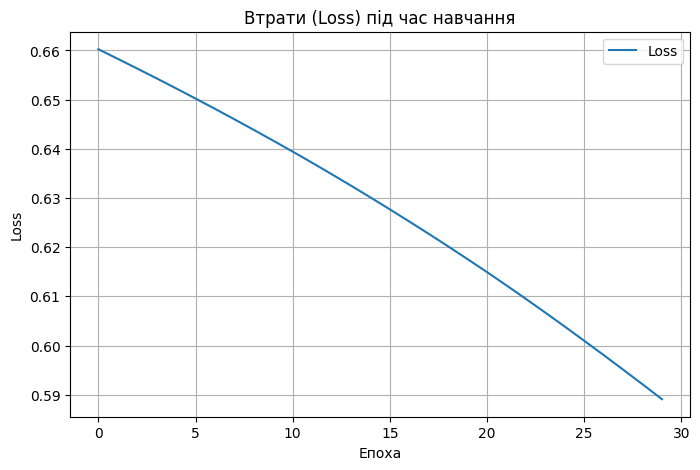

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Loss")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.title("Втрати (Loss) під час навчання")
plt.legend()
plt.grid(True)
plt.savefig("loss_healthrisk_mlp.png")
plt.show()


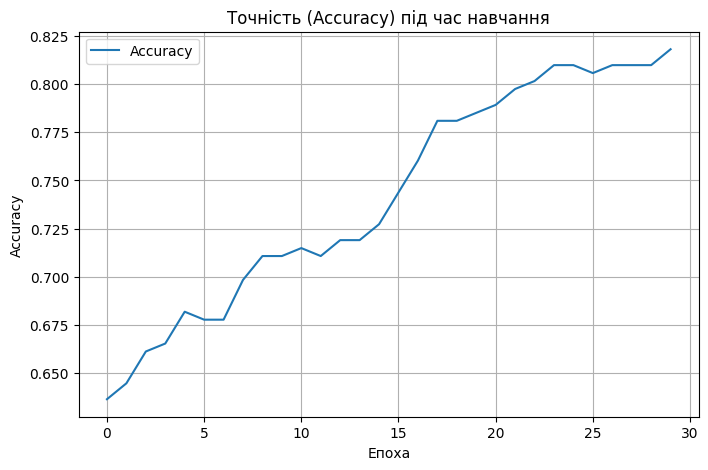

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(accuracy_history, label="Accuracy")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.title("Точність (Accuracy) під час навчання")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_healthrisk_mlp.png")
plt.show()